# LangGraph fundamentals
LangGraph is a framework developed by LangChain (as a company) that helps control and orchestrate
workflows. Unlike many other frameworks, LangGraph allows cycles (most other orchestration frameworks
operate only with directly acyclic graphs), supports streaming out of the box, and has many
pre-built loops and components dedicated to generative AI applications (for example, human
moderation). LangGraph also has a very rich API that allows you to have very granular control
of your execution flow if needed. 

### Understanding State
Typed Dict helps to initiate a dict with defined keys and definite key type of its own instead of default string and string

In [21]:
from typing_extensions import TypedDict

class job_app_state(TypedDict):
    job_desc : str
    is_suitable : bool
    application : str

We have defined schema for our dict lets defined a simple workflow

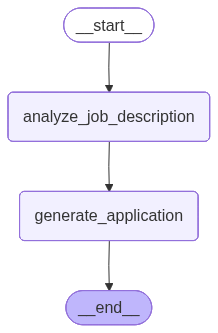

In [22]:
# !pip install -q langgraph
from langgraph.graph import StateGraph, START, END

def analyze_job_desc(state):
    print("Analysing the provided job description")
    return {"is_suitable" : len(state["job_desc"]) > 100}


def generate_application(state):
    print("generating application")
    if state["is_suitable"]:
        return {"application":'genuine_app'}
    else:
        return {"application" : "some_fake_applicatoin"}


builder = StateGraph(job_app_state)
builder.add_node("analyze_job_description", analyze_job_desc)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "analyze_job_description")
builder.add_edge("analyze_job_description","generate_application")
builder.add_edge("generate_application", END)

graph = builder.compile()

graph

In [23]:
graph.invoke({"job_desc" : "fake_job"})

Analysing the provided job description
generating application


{'job_desc': 'fake_job',
 'is_suitable': False,
 'application': 'some_fake_applicatoin'}

The above is a simple graph. We have defined a dict based on the dict we ahve defined a simple graph where if we invoke the the grpah based on the dict key value the flow gets started and the initial dict gets updated. as you have seen in teh above output. We can add conditional edges to the graph and control the flow. Below is an example

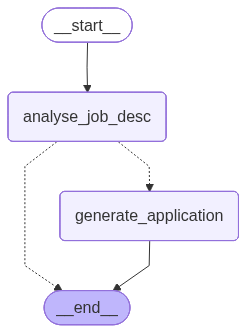

In [24]:
from typing import Literal

builder = StateGraph(job_app_state)
builder.add_node("analyse_job_desc", analyze_job_desc)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state : StateGraph) -> Literal["generate_application", END]:
    if state.get["is_suitable"]:
        return "generate_application"
    else:
        return END


builder.add_edge(START, "analyse_job_desc")
builder.add_conditional_edges("analyse_job_desc", is_suitable_condition)
builder.add_edge("generate_application", END)
graph = builder.compile()

graph

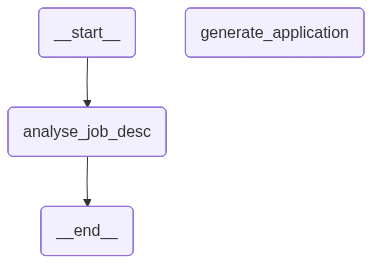

In [25]:
from typing import Literal

builder = StateGraph(job_app_state)
builder.add_node("analyse_job_desc", analyze_job_desc)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state : StateGraph) :
    if state.get["is_suitable"]:
        return "generate_application"
    else:
        return END


builder.add_edge(START, "analyse_job_desc")
builder.add_conditional_edges("analyse_job_desc", is_suitable_condition)
builder.add_edge("generate_application", END)
graph = builder.compile()

graph

In [26]:
# !pip install -q langchain-core
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

### Controlled Output Generation

Since the LLMs may generate output in the format they have been trained or the output they generated might not be the structure we desire/expect we need to control the way the output is generated such that the workflow is not disturbed or disengaged This is called **Controlled Output Generatoin**

In [3]:
# !pip install -q langchain-classic

!pip install --upgrade -q langchain_community langchain_experimental langchain_openai langchainhub chromadb langchain beautifulsoup4 langchain_core langchain_huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 100.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

## Loading an LLM from open Models using Huggingface

In [27]:
from langchain_community.llms import HuggingFacePipeline
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

In [28]:
# model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
# model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
model_id = "Qwen/Qwen2.5-3B-Instruct"
llm =  HuggingFacePipeline(
    pipeline = pipeline(
        task = "text-generation",
        model = AutoModelForCausalLM.from_pretrained(model_id),
        tokenizer = AutoTokenizer.from_pretrained(model_id),
        max_new_tokens = 5,
        device_map = "auto",
        dtype = torch.float16
    )
)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

In [29]:
fake_job_desc = """Job Title: Data Analyst
Location: Remote

Job Overview
We are looking for a Data Analyst to help analyze business data and support decision-making. The candidate will work with multiple teams to extract insights and improve overall performance.

Responsibilities

Collect, clean, and analyze datasets from various sources
Create reports and dashboards to visualize business metrics
Work with stakeholders to understand data requirements
Write SQL queries to extract and manipulate data
Support ongoing analytics and reporting needs


Required Skills

Basic knowledge of Python, SQL, and Excel
Ability to work with data and generate insights
Good communication skills
Familiarity with visualization tools (Tableau / Power BI is a plus)


Qualifications

Bachelor’s degree in any quantitative field
1–3 years of experience preferred"""

In [30]:
prompt_template = (
    "Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRITION : {job_description}"
)

response = llm.invoke(prompt_template.format(job_description = fake_job_desc))
response

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRITION : Job Title: Data Analyst\nLocation: Remote\n\nJob Overview\nWe are looking for a Data Analyst to help analyze business data and support decision-making. The candidate will work with multiple teams to extract insights and improve overall performance.\n\nResponsibilities\n\nCollect, clean, and analyze datasets from various sources\nCreate reports and dashboards to visualize business metrics\nWork with stakeholders to understand data requirements\nWrite SQL queries to extract and manipulate data\nSupport ongoing analytics and reporting needs\n\n\nRequired Skills\n\nBasic knowledge of Python, SQL, and Excel\nAbility to work with data and generate insights\nGood communication skills\nFamiliarity with visualization tools (Tableau / Power BI is a plus)\n\n\nQualifications\n\nBachelor’s degree in any quantitative field\n1–3 years of experience preferred\nExperience with data analysis'

In [31]:
prompt_template = (
    "Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRIPTION : {job_description} Answer only yes or No"
)

response = llm.invoke(prompt_template.format(job_description = fake_job_desc))
response

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRIPTION : Job Title: Data Analyst\nLocation: Remote\n\nJob Overview\nWe are looking for a Data Analyst to help analyze business data and support decision-making. The candidate will work with multiple teams to extract insights and improve overall performance.\n\nResponsibilities\n\nCollect, clean, and analyze datasets from various sources\nCreate reports and dashboards to visualize business metrics\nWork with stakeholders to understand data requirements\nWrite SQL queries to extract and manipulate data\nSupport ongoing analytics and reporting needs\n\n\nRequired Skills\n\nBasic knowledge of Python, SQL, and Excel\nAbility to work with data and generate insights\nGood communication skills\nFamiliarity with visualization tools (Tableau / Power BI is a plus)\n\n\nQualifications\n\nBachelor’s degree in any quantitative field\n1–3 years of experience preferred Answer only yes or No:\nNo\nThe provided'

In [32]:
prompt_template = (
    "You are a text classifier. Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRIPTION : {job_description} Answer only yes or No. NO need of any other information Just answer either an Yes or NO"
)

response = llm.invoke(prompt_template.format(job_description = fake_job_desc))
response

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'You are a text classifier. Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRIPTION : Job Title: Data Analyst\nLocation: Remote\n\nJob Overview\nWe are looking for a Data Analyst to help analyze business data and support decision-making. The candidate will work with multiple teams to extract insights and improve overall performance.\n\nResponsibilities\n\nCollect, clean, and analyze datasets from various sources\nCreate reports and dashboards to visualize business metrics\nWork with stakeholders to understand data requirements\nWrite SQL queries to extract and manipulate data\nSupport ongoing analytics and reporting needs\n\n\nRequired Skills\n\nBasic knowledge of Python, SQL, and Excel\nAbility to work with data and generate insights\nGood communication skills\nFamiliarity with visualization tools (Tableau / Power BI is a plus)\n\n\nQualifications\n\nBachelor’s degree in any quantitative field\n1–3 years of experience preferred Answer only yes 

The output that is generated above needs to be parsed in order for the workflow to carryon. Langchain has lot of output parsers for the same purpose

In [33]:
from enum import Enum
from langchain_classic.output_parsers import EnumOutputParser
from langchain_core.messages import HumanMessage

In [34]:
class is_suitable_job_Enum(Enum):
    YES = "YES"
    NO = "NO"

parser = EnumOutputParser(enum = is_suitable_job_Enum)
assert parser.invoke("NO") == is_suitable_job_Enum.NO
assert parser.invoke(" YES \n") == is_suitable_job_Enum.YES
assert parser.invoke("YES\n") == is_suitable_job_Enum.YES
assert parser.invoke(HumanMessage(content = "YES")) == is_suitable_job_Enum.YES


In [35]:
chain = llm | parser
response = chain.invoke(prompt_template.format(job_description = fake_job_desc))
response

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


OutputParserException: Response 'You are a text classifier. Given a job description decide whehter its suits a junior java developer or not. JOB_DESCRIPTION : Job Title: Data Analyst
Location: Remote

Job Overview
We are looking for a Data Analyst to help analyze business data and support decision-making. The candidate will work with multiple teams to extract insights and improve overall performance.

Responsibilities

Collect, clean, and analyze datasets from various sources
Create reports and dashboards to visualize business metrics
Work with stakeholders to understand data requirements
Write SQL queries to extract and manipulate data
Support ongoing analytics and reporting needs


Required Skills

Basic knowledge of Python, SQL, and Excel
Ability to work with data and generate insights
Good communication skills
Familiarity with visualization tools (Tableau / Power BI is a plus)


Qualifications

Bachelor’s degree in any quantitative field
1–3 years of experience preferred Answer onl

The above error occured becuz we have put a Enum parser which expect a "YES" or "NO" but our LLM reponse consists of a defined paragraph hence the parser isnt able to decode or work properly casuing the error. Asusming that the parser is working fine lets integrate or LLM into our workflow

/usr/local/lib/python3.12/dist-packages/langgraph/graph/state.py:116: UserWarning: Invalid state_schema: <function job_application_state at 0x7fdff4ba7a60>. Expected a type or Annotated[type, reducer]. Please provide a valid schema to ensure correct updates.
 See: https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph
  warnings.warn(


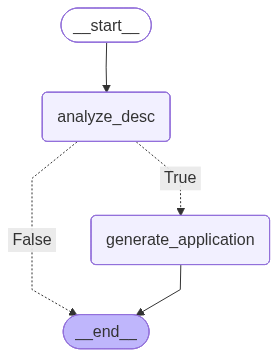

In [39]:
def job_application_state(TypedDict):
    job_desc : str
    is_suitable : bool
    application  : str


analyze_chain = llm | parser

def analyze_job_description(state):
    prompt = prompt_template.format(job_prescription = state["job_desc"])
    result = analyze_chain.invoke(prompt)
    return  is_suitable[result]

def is_suitable_condition(state):
    return state['is_suitable'] == is_suitable_job_Enum.YES

builder = StateGraph(job_application_state)
builder.add_node("analyze_desc", analyze_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "analyze_desc")
# builder.add_edges()
builder.add_conditional_edges("analyze_desc", is_suitable_condition, {True : "generate_application", False : END})
builder.add_edge("generate_application", END)

graph = builder.compile()

graph